In [38]:
from sklearn.datasets import make_regression,make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse,r2_score
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from matplotlib import pyplot as plt
import pandas as pd

In [10]:
X,y = make_regression(n_samples= 500,n_features=1,noise=15,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Lets try our regressor with simple data

In [11]:
class GBMRegressor:
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, random_state=0):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        self.initial_leaf = y.mean()
        predictions = np.zeros(len(y)) + self.initial_leaf

        for _ in range(self.n_estimators):
            residuals = y - predictions
            tree = DecisionTreeRegressor(criterion='friedman_mse', max_depth=self.max_depth,
                                         random_state=self.random_state)
            tree.fit(X, residuals)
            predictions += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, samples):
        predictions = np.zeros(len(samples)) + self.initial_leaf

        for i in range(self.n_estimators):
            predictions += self.learning_rate * self.trees[i].predict(samples)

        return predictions

# How number estimators affects on metrics and training

In [14]:
for i in [1,5,10,50,100]:
  gbm_reg = GBMRegressor(n_estimators=i)
  gbm_reg.fit(X_train, y_train)
  y_pred_1 = gbm_reg.predict(X_train)
  y_pred_2 = gbm_reg.predict(X_test)
  print('MSE for training data:', mse(y_pred_1,y_train))
  print('MSE for training data:', mse(y_pred_2,y_test),'\n')

MSE for training data: 3513.5251192904416
MSE for training data: 2969.0319362041228 

MSE for training data: 1678.5043034572043
MSE for training data: 1466.29419669704 

MSE for training data: 735.3181371044141
MSE for training data: 688.7033864951176 

MSE for training data: 161.81842816940775
MSE for training data: 210.46104041336915 

MSE for training data: 131.40459853809435
MSE for training data: 220.590885373524 



# Graph shows how data is placed on 2d and how regression line

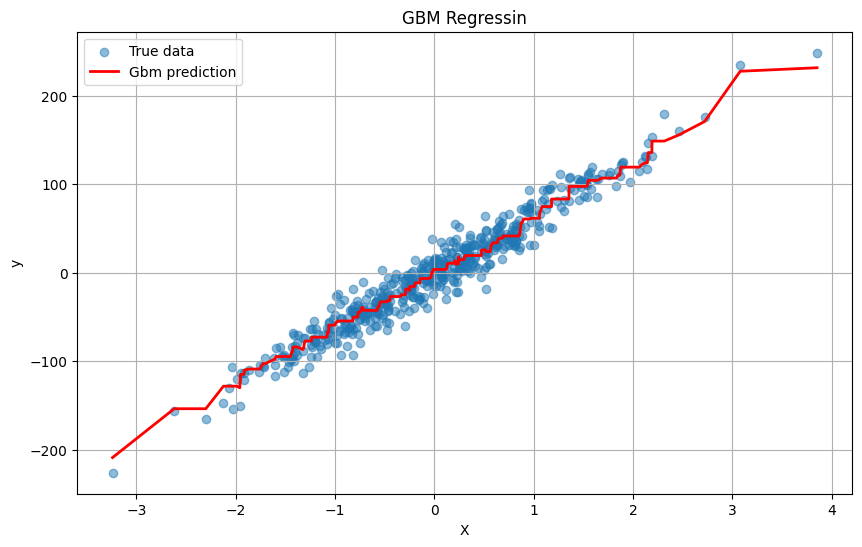

In [18]:

model = GBMRegressor(n_estimators=50, learning_rate=0.1, max_depth=2)
model.fit(X_train, y_train)
y_pred = model.predict(X)
plt.figure(figsize=(10,6))
plt.scatter(X, y,label='True data',alpha=0.5)
plt.plot(X,y_pred,color= 'red',linewidth=2,label= 'Gbm prediction')
plt.title("GBM Regression")
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()


# Modifying our regressor to collect train losses

In [17]:
class GBMRegressor:
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, random_state=0):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        self.train_losses= []

    def fit(self, X, y):
        self.initial_leaf = y.mean()
        predictions = np.zeros(len(y)) + self.initial_leaf

        for _ in range(self.n_estimators):
            residuals = y - predictions
            tree = DecisionTreeRegressor(criterion='friedman_mse', max_depth=self.max_depth,
                                         random_state=self.random_state)
            tree.fit(X, residuals)
            predictions += self.learning_rate * tree.predict(X)
            loss = np.mean((y - predictions) ** 2)
            self.train_losses.append(loss)
            self.trees.append(tree)

    def predict(self, samples):
        predictions = np.zeros(len(samples)) + self.initial_leaf

        for i in range(self.n_estimators):
            predictions += self.learning_rate * self.trees[i].predict(samples)

        return predictions

# The chart shows the loss decreasing as each subsequent tree is trained. We see that after 20 trees, only minor changes occur.

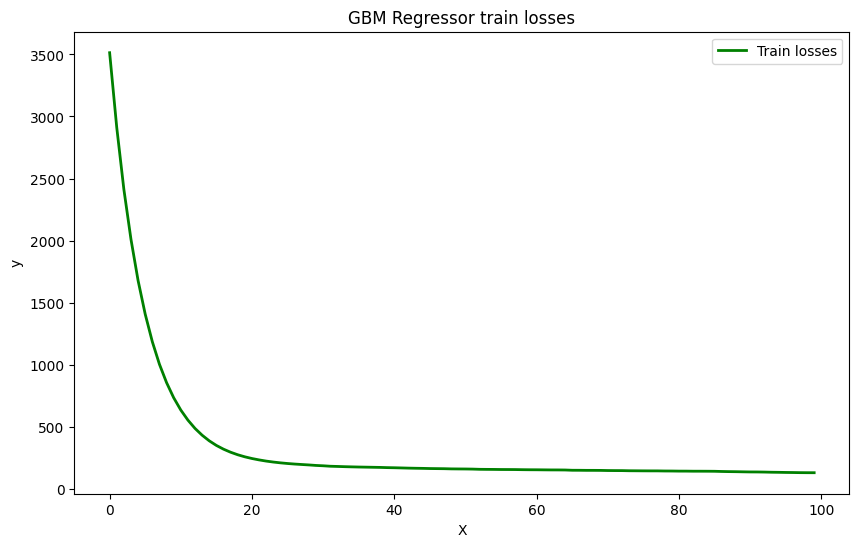

In [19]:
gbm_reg = GBMRegressor(n_estimators=100)
gbm_reg.fit(X_train, y_train)
plt.figure(figsize=(10,6))
plt.plot(gbm_reg.train_losses,color='green',linewidth=2, label ='Train losses')
plt.title("GBM Regressor train losses")
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# What is role of learning rate?

In [20]:
for i in [1.0,0.3,0.1,0.01]:
  gbm_reg = GBMRegressor(learning_rate=i,n_estimators=50)
  gbm_reg.fit(X_train, y_train)
  y_pred_1 = gbm_reg.predict(X_train)
  y_pred_2 = gbm_reg.predict(X_test)
  print('MSE for training data:', mse(y_pred_1,y_train))
  print('MSE for training data:', mse(y_pred_2,y_test),'\n')

MSE for training data: 39.965206285666916
MSE for training data: 378.23098362543817 

MSE for training data: 108.87882845742304
MSE for training data: 240.30890788802807 

MSE for training data: 161.81842816940775
MSE for training data: 210.46104041336915 

MSE for training data: 1747.0596939206716
MSE for training data: 1515.4135318527638 



A learning rate of 1 is too high — the model overshoots and behaves erratically across the data.A learning rate of 0.01 is too low — it reduces MSE very slowly, taking many tiny steps.Learning rates of 0.1 and 0.3 strike a good balance and are optimal parameters.

In [21]:
for i in [1,2,3,5]:
  gbm_reg = GBMRegressor(max_depth=i)
  gbm_reg.fit(X_train, y_train)
  y_pred_1 = gbm_reg.predict(X_train)
  y_pred_2 = gbm_reg.predict(X_test)
  print('MSE for training data:', mse(y_pred_1,y_train))
  print('MSE for training data:', mse(y_pred_2,y_test),'\n')

MSE for training data: 191.405548264678
MSE for training data: 216.04471110665318 

MSE for training data: 164.36803703836205
MSE for training data: 208.44646421842273 

MSE for training data: 131.40459853809435
MSE for training data: 220.590885373524 

MSE for training data: 64.86845384738645
MSE for training data: 265.75640710927905 



# Decision Tree vs Gradient boosting

In [23]:
dt = DecisionTreeRegressor(max_depth=3)
gbm_reg = GBMRegressor(max_depth=3,n_estimators=100)
gbm_reg.fit(X_train, y_train)
dt.fit(X_train,y_train)
y_pred_gbm = gbm_reg.predict(X_test)
y_pred_dt = dt.predict(X_test)
print("GBM MSE: ",mse(y_pred_gbm,y_test))
print("DT MSE: ",mse(y_pred_dt,y_test))

GBM MSE:  220.590885373524
DT MSE:  264.1856110402932


Ensemble of decision trees is much more stable and accurate than single tree

# Now GBM Classifier

In [36]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

class GBMClassifier:
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, random_state=0):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state

    def _softmax(self, scores):
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp = np.exp(shifted)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.K = len(self.classes_)
        self.trees = {k: [] for k in range(self.K)}

        y_onehot = pd.get_dummies(y).reindex(columns=self.classes_, fill_value=0).to_numpy()
        scores = np.zeros((len(X), self.K))

        for _ in range(self.n_estimators):
            probabilities = self._softmax(scores)

            for k in range(self.K):
                residuals = y_onehot[:, k] - probabilities[:, k]

                tree = DecisionTreeRegressor(
                    criterion='friedman_mse',
                    max_depth=self.max_depth,
                    random_state=self.random_state
                )
                tree.fit(X, residuals)
                self.trees[k].append(tree)

                scores[:, k] += self.learning_rate * tree.predict(X)

        return self

    def predict_proba(self, X):
        scores = np.zeros((len(X), self.K))

        for i in range(self.n_estimators):
            for k in range(self.K):
                scores[:, k] += self.learning_rate * self.trees[k][i].predict(X)

        return self._softmax(scores)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        class_indices = np.argmax(probabilities, axis=1)
        return self.classes_[class_indices]

# Simple test for our realisation

In [40]:
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gbm_clf = GBMClassifier()
gbm_clf.fit(X_train, y_train)
pred = gbm_clf.predict(X_test)


In [41]:
print('Accuracy for train data: ',accuracy_score(gbm_clf.predict(X_train),y_train))
print('Accuracy for test data: ',accuracy_score(pred,y_test))

Accuracy for train data:  0.9775
Accuracy for test data:  0.93


# Graph shows how out model divided 2 classes on space


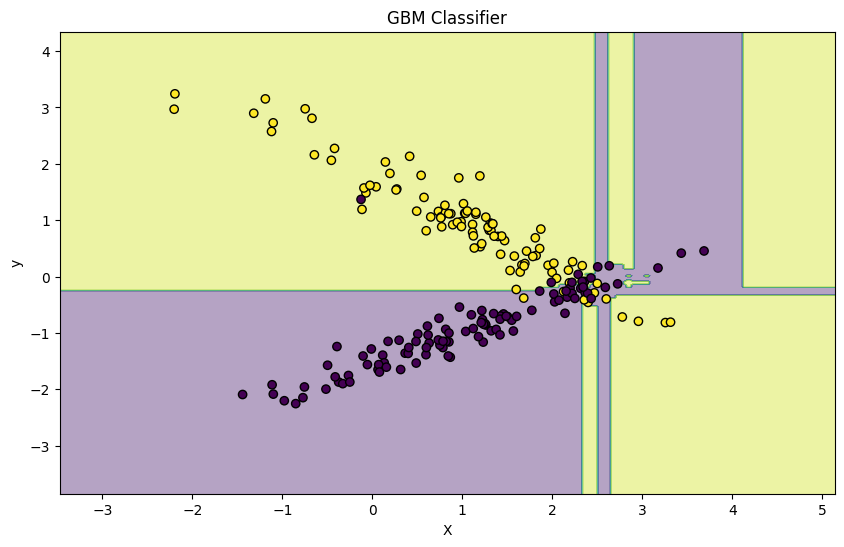

In [45]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = gbm_clf.predict(grid).reshape(xx.shape)
Z= Z.reshape(xx.shape)
plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,edgecolor='k')
plt.xlabel('X')
plt.ylabel('y')
plt.title('GBM Classifier')
plt.show()

# More metrics for multiclass classification

In [48]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
gbm_clf = GBMClassifier()
gbm_clf.fit(X_train, y_train)
print("Accuracy: ",accuracy_score(gbm_clf.predict(X_test),y_test))
print("Confusion matrix: \n",confusion_matrix(gbm_clf.predict(X_test),y_test))
print("Classification report: \n",classification_report(gbm_clf.predict(X_test),y_test))

Accuracy:  0.845
Confusion matrix: 
 [[50  0  4]
 [ 9 59  7]
 [ 5  6 60]]
Classification report: 
               precision    recall  f1-score   support

           0       0.78      0.93      0.85        54
           1       0.91      0.79      0.84        75
           2       0.85      0.85      0.85        71

    accuracy                           0.84       200
   macro avg       0.84      0.85      0.85       200
weighted avg       0.85      0.84      0.84       200



Accuracy is the fraction of correctly classified instances. In multiclass settings, it's simple and intuitive but can be misleading when classes are imbalanced.

Confusion Matrix – shows true vs. predicted counts for each class, helping identify which classes are often confused.

Precision, Recall, and F1‑score per class – evaluate performance on a per‑class basis.